# Compositional generation demonstration with ShEPhERD-2

This tutorial demonstrates how to compose multiple interaction profiles with ShEPhERD-2, generating new molecules that combine (or negate) the shape, electrostatic, and pharmacophoric features of two reference ligands. We cover these use-cases:
- Loading and aligning two reference ligands
- Extracting interaction profiles for composition
- Compositional generation (AND / AND NOT)
- Inspecting generation trajectories
- Extracting and evaluating generated samples
- Atom/scaffold-conditioned composition


In [ ]:
%load_ext autoreload
%autoreload 2

import os
import pickle
import time

import numpy as np
import matplotlib.pyplot as plt

import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem

import torch
# faster inference
torch.set_float32_matmul_precision('high')

from shepherd_score.visualize import draw_sample, view_sample_trajectory, draw_2d_highlight
from shepherd_score.container import Molecule
from shepherd_score.evaluations.evaluate.pipelines import ConditionalEvalPipeline

from shepherd import load_model
from shepherd.interaction_profile import extract_interaction_profile, ConditionAtoms
from shepherd.extract import create_rdkit_molecule
import shepherd.comp_inference.utils as utils


## 1. Load the model
Downloads from Huggingface automatically.


In [ ]:
model = load_model(
    model_type='mosesaq',
    inference_only=True,
    device='cuda'
)
params = model.params


## 2. Load the two reference ligands and align them

We load a set of example ligands (with pre-computed xTB partial charges) from a subset of the MOSES test set, then align one onto the other with `align_two_ref_mol`. Aligning the two references onto a shared frame is required before we can combine their interaction profiles for compositional generation. Here we align molecule `ind1` onto `ind2` using electrostatic similarity (`condition='esp'`).


In [ ]:
# Path is relative to this notebook's location (examples/) so it works for any repo checkout.
path = "../data/conformers/moses_aq/moses_test_scaffold_molblock_charges.pkl"
with open(path, 'rb') as f:
    molblocks_and_charges = pickle.load(f)

ind1 = 24
ind2 = 81

aligned_mol = utils.align_two_ref_mol(
    molblocks_and_charges,
    mol_to_align_i=ind1,
    ref_mol_i=ind2,
    condition='esp',
)

ref_mol2 = Chem.MolFromMolBlock(molblocks_and_charges[ind2][0], removeHs=False)


## 3. Extract interaction profiles

The pre-computed xTB partial charges from the pickle are passed directly, so we set `xtb_optimize=False` for both molecules. As before, `center=True` translates each profile's COM to the origin; since we already aligned the two ligands, we re-translate `profile1` afterwards so both profiles share the same reference frame as `profile2`.


In [29]:
profile1 = extract_interaction_profile(
    aligned_mol,
    xtb_optimize=False,
    partial_charges=np.array(molblocks_and_charges[ind1][1]),
    center=True,
)
profile2 = extract_interaction_profile(
    ref_mol2,
    xtb_optimize=False,
    partial_charges=np.array(molblocks_and_charges[ind2][1]),
    center=True,
)

#ensure same reference frame centered on COM of profile 2
profile1.translated(profile2.com_before_centering - profile1.com_before_centering)

print(f"profile1: n_atoms={profile1.n_atoms}, n_pharms={profile1.n_pharms}")
print(f"profile2: n_atoms={profile2.n_atoms}, n_pharms={profile2.n_pharms}")


profile1: n_atoms=33, n_pharms=10
profile2: n_atoms=35, n_pharms=11


## 4. Compositional generation: `model.generate_composition`

Compositional generation combines multiple interaction profiles using signed `weights_conditions`. Equal, positive weights on both profiles ask for molecules that satisfy both (an "AND"), while giving one profile a negative weight asks for molecules that satisfy the first profile while avoiding the features of the second (an "AND NOT"). `composition_mode` controls how the weighted profiles are combined during inpainting (`'default'` vs `'conditional'`), and `early_stop_edm` stops the EDM sampler early (here, after 90% of the trajectory) once generation has mostly converged.


In [ ]:
N = 400

start = time.time()

# AND: equal, positive weights ask for samples that satisfy both profile1 and profile2
weights = np.array([0.5, 0.5])
outputs = model.generate_composition(
    N_x1=profile2.n_atoms + 5,
    N_x4=profile2.n_pharms,
    batch_size=20,
    profiles=[profile1, profile2],
    atom_condition=None,
    weights_conditions=weights,
    composition_mode='default',
    early_stop_edm=int(0.9 * N),
    store_trajectories=True,
)
elapsed = time.time() - start
print(f"Generated {len(outputs)} samples in {elapsed:.1f} s")


In [ ]:
N = 400

start = time.time()

# AND NOT: negative weight on profile2 asks for samples that satisfy profile1 while avoiding
# profile2's features
weights = np.array([0.5, -0.5])
outputs = model.generate_composition(
    N_x1=profile2.n_atoms + 5,
    N_x4=profile2.n_pharms,
    batch_size=20,
    profiles=[profile1, profile2],
    atom_condition=None,
    weights_conditions=weights,
    composition_mode='conditional',
    early_stop_edm=int(0.9 * N),
    store_trajectories=True,
)
elapsed = time.time() - start
print(f"Generated {len(outputs)} samples in {elapsed:.1f} s")
torch.cuda.empty_cache()


## 5. Sanity check the x1 trajectory

Before extracting molecules, it's useful to check that the EDM sampler actually converged. We visualize the atom-position (`x1`) trajectory in 3D, then plot the maximum electrostatic-surface (`x3`) position per denoising step - this should asymptote as the trajectory converges.


In [ ]:
view_sample_trajectory(outputs[0], only_atoms=True, trajectory='x')


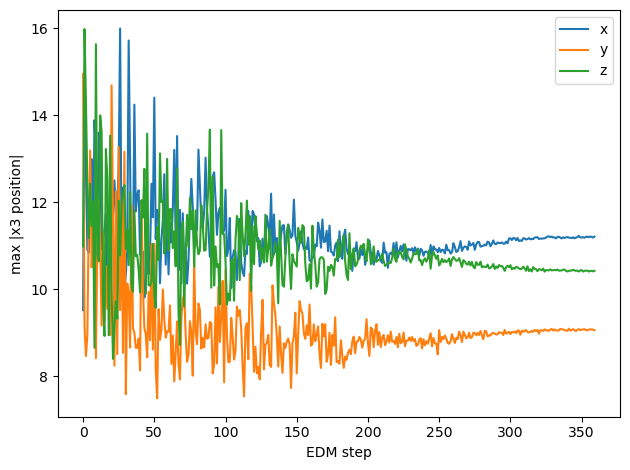

In [54]:
batch_ind = 0
traj_x3 = np.array([
    np.abs(step['x3']['positions']).max(0)
    for step in outputs[batch_ind]['trajectories'][1:]
])

plt.plot(range(len(traj_x3)), traj_x3)
plt.legend(['x', 'y', 'z'])
plt.xlabel('EDM step')
plt.ylabel('max |x3 position|')
plt.tight_layout()
plt.show()


## 6. Extraction / processing: samples -> RDKit mols -> SMILES

As in the earlier tutorials, we can convert generated samples to RDKit `Mol` objects in two ways:
- A quick conversion via `create_rdkit_molecule`, followed by an MMFF optimization — fast, but does not recompute partial charges.
- A xTB-relaxed conversion via `GeneratedSample.to_mol_charges()`, which also returns the xTB partial charges for each generated molecule. This is slower but gives higher-quality structures and charges.


In [41]:
# Quick conversion, no xTB relaxation 
quick_mols = []
for sample in outputs:
    mol = create_rdkit_molecule(sample)
    if mol is not None:
        mol = Chem.RemoveHs(mol)
        AllChem.MMFFOptimizeMolecule(mol)
    quick_mols.append(mol)

quick_smiles = [Chem.MolToSmiles(m) if m is not None else None for m in quick_mols]
print(quick_smiles)


[12:53:43] Molecule does not have explicit Hs. Consider calling AddHs()
[12:53:43] Molecule does not have explicit Hs. Consider calling AddHs()
[12:53:43] Molecule does not have explicit Hs. Consider calling AddHs()
[12:53:43] Molecule does not have explicit Hs. Consider calling AddHs()
[12:53:43] Molecule does not have explicit Hs. Consider calling AddHs()
[12:53:43] Molecule does not have explicit Hs. Consider calling AddHs()
[12:53:43] Molecule does not have explicit Hs. Consider calling AddHs()
[12:53:43] Molecule does not have explicit Hs. Consider calling AddHs()
[12:53:43] Molecule does not have explicit Hs. Consider calling AddHs()
[12:53:43] Molecule does not have explicit Hs. Consider calling AddHs()
2026-09-03 12:53:43,478 - root - WARNING - Molecule is a fragment


['CCCCC1=Cn2cccc2N=C1NCC1CC1', 'CSc1cc(/C=C/CC2CC2)c2c(n1)CCCC2', 'Cc1nc2c(/c(=C/OC3CC3)cc1Cl)CN[C@@H](C)C2', 'CCN(C)C1=Nn2cccc2C(NCC(C)C)=N1', 'C[C@@H]1CC2=C(C1)c1cccn1/C2=[NH+]/[C@@H]1[C@@H](C)[C@@H]1O', 'CCCCOc1cc(C(C)C)nc2ccccc12', 'CCC/[NH+]=C/c1c2ccccc2nc2cccnc12', 'CCC/[NH+]=C/c1cc(N(C)C)nc2ccccc12', 'CCC1=C[C+]([C@@H]2C[C@H]2CC)C2=NC=CC=CC2=N1', 'CCCNC1=Nc2ccccc2N(CCNC)C1=O', None, None, 'CCNC(=O)Cc1cccc2nc(C(C)C)[nH]c12', 'CCNc1nc(OC[C@H]2C[C@@H]2C)c2ccccc2n1', 'CCCC/C=C1\\C(c2ccccc2)=[N+]=C2CCCN21', 'CCCc1nc2ccc(F)cc2nc1NCC1CC1', 'CCC[C@H]1Oc2cc(F)cc3c2N1C(=O)[C@H](CC)C3', 'CCCN/C=C1\\N=C2C=CC=CC2=[N+]=C1CCC', 'CCCCc1cc(CCC)nc2ccc(Cl)cc12', 'C(=[N+]=C1C=CC=CC1=C=CCC1CC1)=C1CCCC1']


[12:53:43] Molecule does not have explicit Hs. Consider calling AddHs()
[12:53:43] Molecule does not have explicit Hs. Consider calling AddHs()
[12:53:43] Molecule does not have explicit Hs. Consider calling AddHs()
[12:53:43] Molecule does not have explicit Hs. Consider calling AddHs()
[12:53:43] Molecule does not have explicit Hs. Consider calling AddHs()
[12:53:43] Molecule does not have explicit Hs. Consider calling AddHs()
[12:53:43] Molecule does not have explicit Hs. Consider calling AddHs()
[12:53:43] Molecule does not have explicit Hs. Consider calling AddHs()


In [52]:
# xTB-relaxed conversion + partial charges
relaxed_mols, relaxed_charges = [], []
for sample in outputs:
    mol, charges = sample.to_mol_charges(xtb_optimize=True, xtb_timeout=180)
    relaxed_mols.append(mol)
    relaxed_charges.append(charges)

relaxed_smiles = [
    Chem.MolToSmiles(Chem.RemoveHs(m)) if m is not None else None
    for m in relaxed_mols
]
print(relaxed_smiles)


2026-09-03 13:09:04,348 - root - WARNING - Molecule is a fragment


['CCCCc1cn2cccc2nc1NCC1CC1', 'CSc1cc(/C=C/CC2CC2)c2c(n1)CCCC2', 'CC1=NC2=C(CN[C@@H](C)C2)/C(=C/OC2CC2)C=C1Cl', 'CCN(C)c1nc(NCC(C)C)c2cccn2n1', 'C[C@@H]1CC2=C(C1)c1cccn1/C2=[NH+]/[C@@H]1[C@@H](C)[C@@H]1O', 'CCCCOc1cc(C(C)C)nc2ccccc12', 'CCC/[NH+]=C/c1c2ccccc2nc2cccnc12', 'CCC/[NH+]=C/c1cc(N(C)C)nc2ccccc12', 'CCc1c[c+]([C@@H]2C[C@H]2CC)c2nccccc-2n1', 'CCCNc1nc2ccccc2n(CCNC)c1=O', None, None, 'CCNC(=O)Cc1cccc2nc(C(C)C)[nH]c12', 'CCNc1nc(OC[C@H]2C[C@@H]2C)c2ccccc2n1', 'CCCC/C=C1\\C(c2ccccc2)=[N+]=C2CCCN21', 'CCCc1nc2ccc(F)cc2nc1NCC1CC1', 'CCC[C@H]1Oc2cc(F)cc3c2N1C(=O)[C@H](CC)C3', 'CCCN/C=C1\\N=c2ccccc2=[N+]=C1CCC', 'CCCCc1cc(CCC)nc2ccc(Cl)cc12', 'C1=CC2=NC(=C3CCCC3)/C(=C\\CC3CC3)[C+]2C=C1']


## 7. Visualize a generated sample against each reference

We overlay a single generated sample against each of the two reference ligands to see how the composed molecule relates to both.


In [59]:
sample_ind = 10
draw_sample(generated_sample=outputs[sample_ind], ref_mol=profile2.mol, only_atoms=True)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [60]:
draw_sample(generated_sample=outputs[sample_ind], ref_mol=profile1.mol, only_atoms=True)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 8. Evaluate against the anchor condition with shepherd-score

We evaluate the generated samples against `profile2` (the anchor condition) using shepherd-score's `ConditionalEvalPipeline`. `pipeline.num_valid` counts samples that parsed to a valid molecule, and `pipeline.num_valid_post_opt` counts samples that remained valid after the pipeline's post-generation optimization/relaxation step.


In [ ]:
pipeline = ConditionalEvalPipeline(
    **model.to_shepherd_score_inputs(
        outputs,
        condition=profile2,
        condition_modalities='all',
    )
)
pipeline.evaluate(num_workers=1, num_processes=1, verbose=True)
print(
    f"valid={pipeline.num_valid}/{len(outputs)}, "
    f"valid_post_opt={pipeline.num_valid_post_opt}/{len(outputs)}"
)


In [ ]:
properties_df, global_attr = pipeline.to_pandas()
global_attr.head()


## 9. Atom/scaffold-conditioned composition

Just like single-profile generation, compositional generation supports fixing a subset of atoms (a scaffold) throughout denoising. We first pick the atom indices to keep from `profile2` and visualize them, then build a `ConditionAtoms` object and pass it as `atom_condition` with `scaffold_conditioning=True` to `model.generate_composition`.


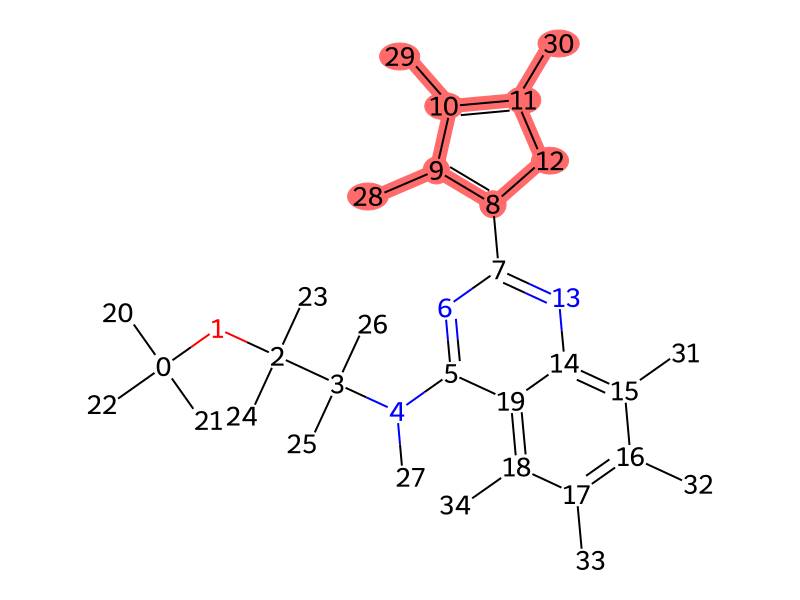

In [93]:
atoms_to_keep = [8, 9, 10, 11, 12, 28, 29, 30]
draw_2d_highlight(profile2.mol, atom_sets = [atoms_to_keep], label='atomLabel')


In [94]:
scaffold_condition = ConditionAtoms.from_mol(profile2.mol, inds=atoms_to_keep)


In [ ]:
# AND: equal, positive weights, with the scaffold atoms fixed throughout denoising
weights = np.array([0.5, 0.5])
scaffold_outputs = model.generate_composition(
    N_x1=profile2.n_atoms + 5,
    N_x4=profile2.n_pharms,
    batch_size=20,
    profiles=[profile1, profile2],
    atom_condition=scaffold_condition,
    scaffold_conditioning=True,
    weights_conditions=weights,
    composition_mode='default',
    shepherd_pred=True,
    early_stop_edm=int(0.9 * N),
)


In [ ]:
# AND NOT: negative weight on profile1, with the scaffold atoms fixed throughout denoising
weights = np.array([0.5, -0.5])
outputs = model.generate_composition(
    N_x1=profile2.n_atoms + 5,
    N_x4=profile2.n_pharms,
    batch_size=20,
    profiles=[profile2, profile1],
    atom_condition=scaffold_condition,
    scaffold_conditioning=True,
    weights_conditions=weights,
    composition_mode='conditional',
    early_stop_edm=int(0.9 * N),
    store_trajectories=True,
)


In [89]:
sample_ind = 10
draw_sample(generated_sample=scaffold_outputs[sample_ind], ref_mol=profile2.mol, only_atoms=True)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [90]:
draw_sample(generated_sample=scaffold_outputs[sample_ind], ref_mol=profile1.mol, only_atoms=True)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.